## Import de librerías

In [44]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import glob
import polars as pl
import timeit

## Import de dataset

In [56]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/02-preprocessed/yellow_tripdata_2024-01.parquet")

# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)


1 files merged
(2646948, 23)


## Tratamiento de valores nulos

### Análisis general

In [57]:
# Crea un sub-DataFrame con las filas que tienen CUALQUIER valor nulo
nulos_subdf = df[df.isnull().any(axis=1)]

# Muestra el número de filas encontradas
print(f"Total de filas con al menos un valor nulo: {len(nulos_subdf)}")

# Muestra las primeras 5 filas para su inspección
nulos_subdf.head(5)

Total de filas con al menos un valor nulo: 145258


,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
21,"Creative Mobile Technologies, LLC",2024-01-01 00:14:29,2024-01-01 00:14:29,1,0.00,Standard rate,False,Cash,3.00,3.50,...,1.00,8.00,2.50,0.00,Manhattan,Upper East Side North,Yellow Zone,Unknown,None,None
22,"Creative Mobile Technologies, LLC",2024-01-01 00:42:05,2024-01-01 01:16:49,1,23.90,Negotiated fare,False,Credit card,120.00,0.00,...,1.00,127.94,0.00,0.00,Manhattan,Yorkville West,Yellow Zone,None,Outside of NYC,None
116,"Creative Mobile Technologies, LLC",2024-01-01 00:34:00,2024-01-01 00:56:49,2,2.90,Standard rate,False,Credit card,21.20,3.50,...,1.00,30.13,2.50,0.00,Manhattan,Central Park,Yellow Zone,Unknown,None,None
190,"Creative Mobile Technologies, LLC",2024-01-01 00:15:16,2024-01-01 00:26:58,2,0.00,Standard rate,False,Credit card,10.70,3.50,...,1.00,18.80,2.50,0.00,Manhattan,East Village,Yellow Zone,Unknown,None,None
191,"Creative Mobile Technologies, LLC",2024-01-01 00:39:34,2024-01-01 01:04:02,1,0.00,Standard rate,False,Credit card,19.80,3.50,...,1.00,26.80,2.50,0.00,Manhattan,Midtown Center,Yellow Zone,Unknown,None,None


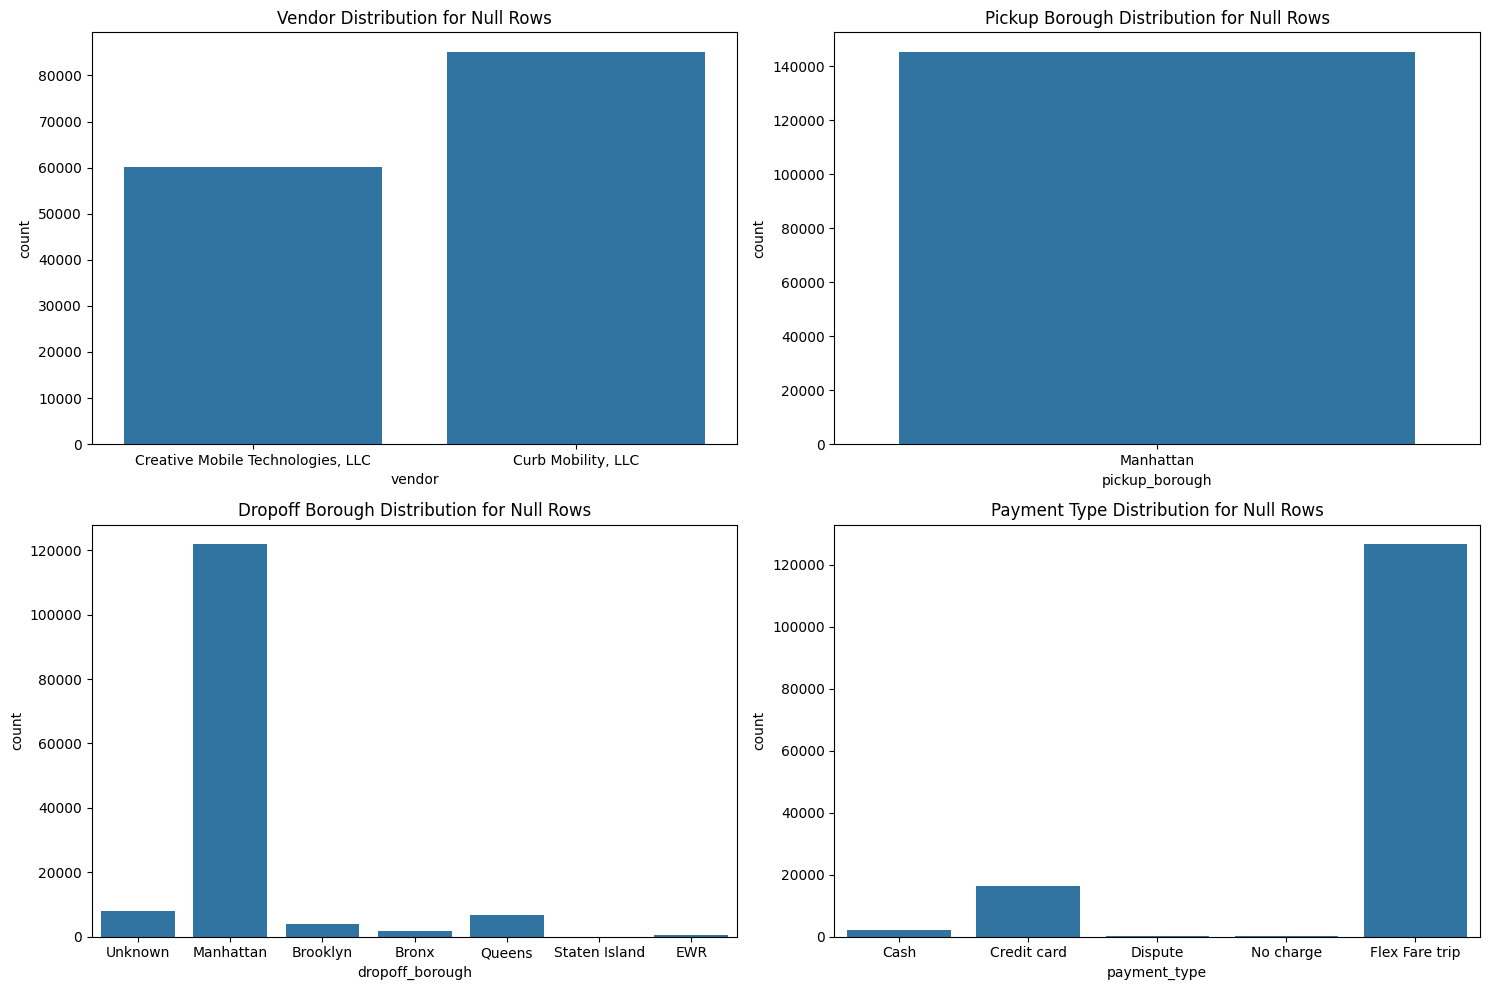

In [47]:
# subplots con: vendor, pickup_borough, dropoff_borough, payment_type
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(data=nulos_subdf, x='vendor', ax=axes[0,0])
axes[0,0].set_title('Vendor Distribution for Null Rows')
sns.countplot(data=nulos_subdf, x='pickup_borough', ax=axes[0,1])
axes[0,1].set_title('Pickup Borough Distribution for Null Rows')
sns.countplot(data=nulos_subdf, x='dropoff_borough', ax=axes[1,0])
axes[1,0].set_title('Dropoff Borough Distribution for Null Rows')
sns.countplot(data=nulos_subdf, x='payment_type', ax=axes[1,1])
axes[1,1].set_title('Payment Type Distribution for Null Rows')
plt.tight_layout()

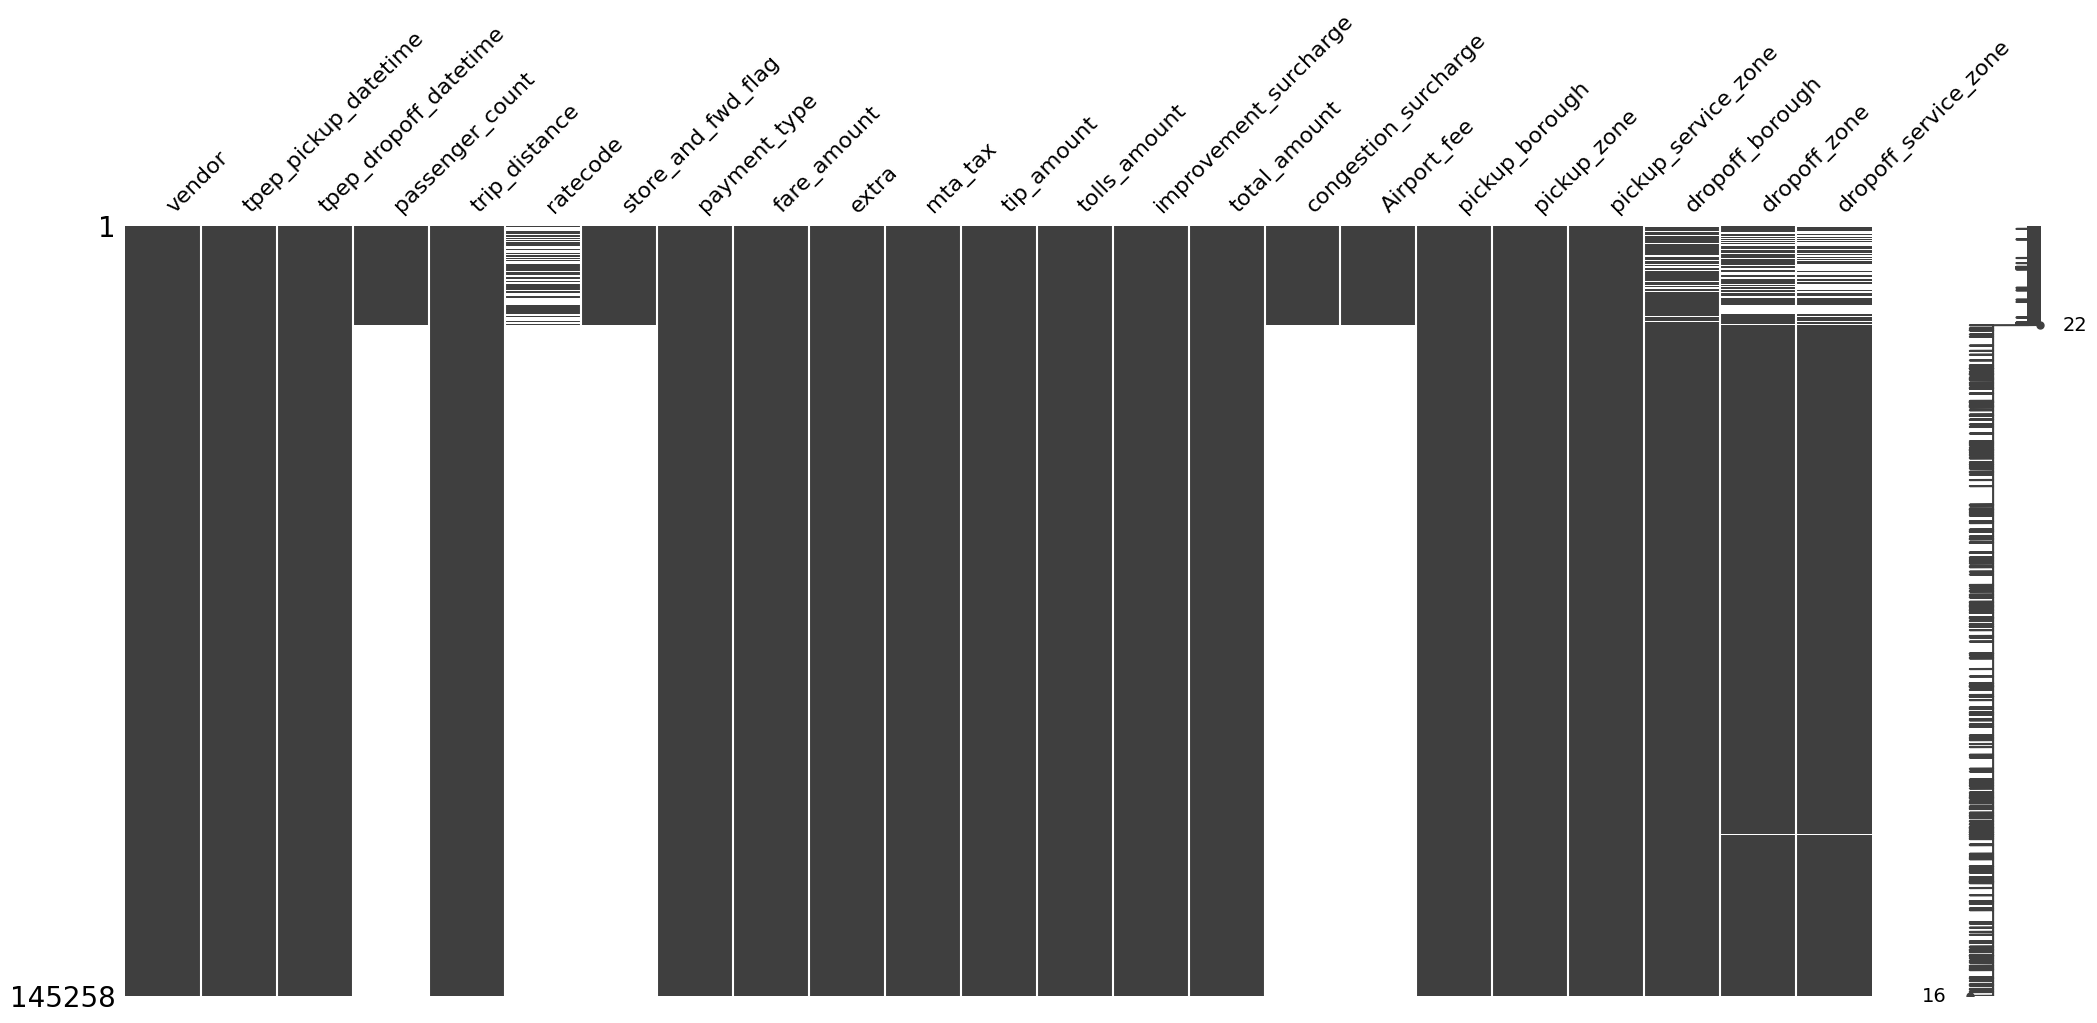

In [48]:
msno.matrix(nulos_subdf)
plt.show()

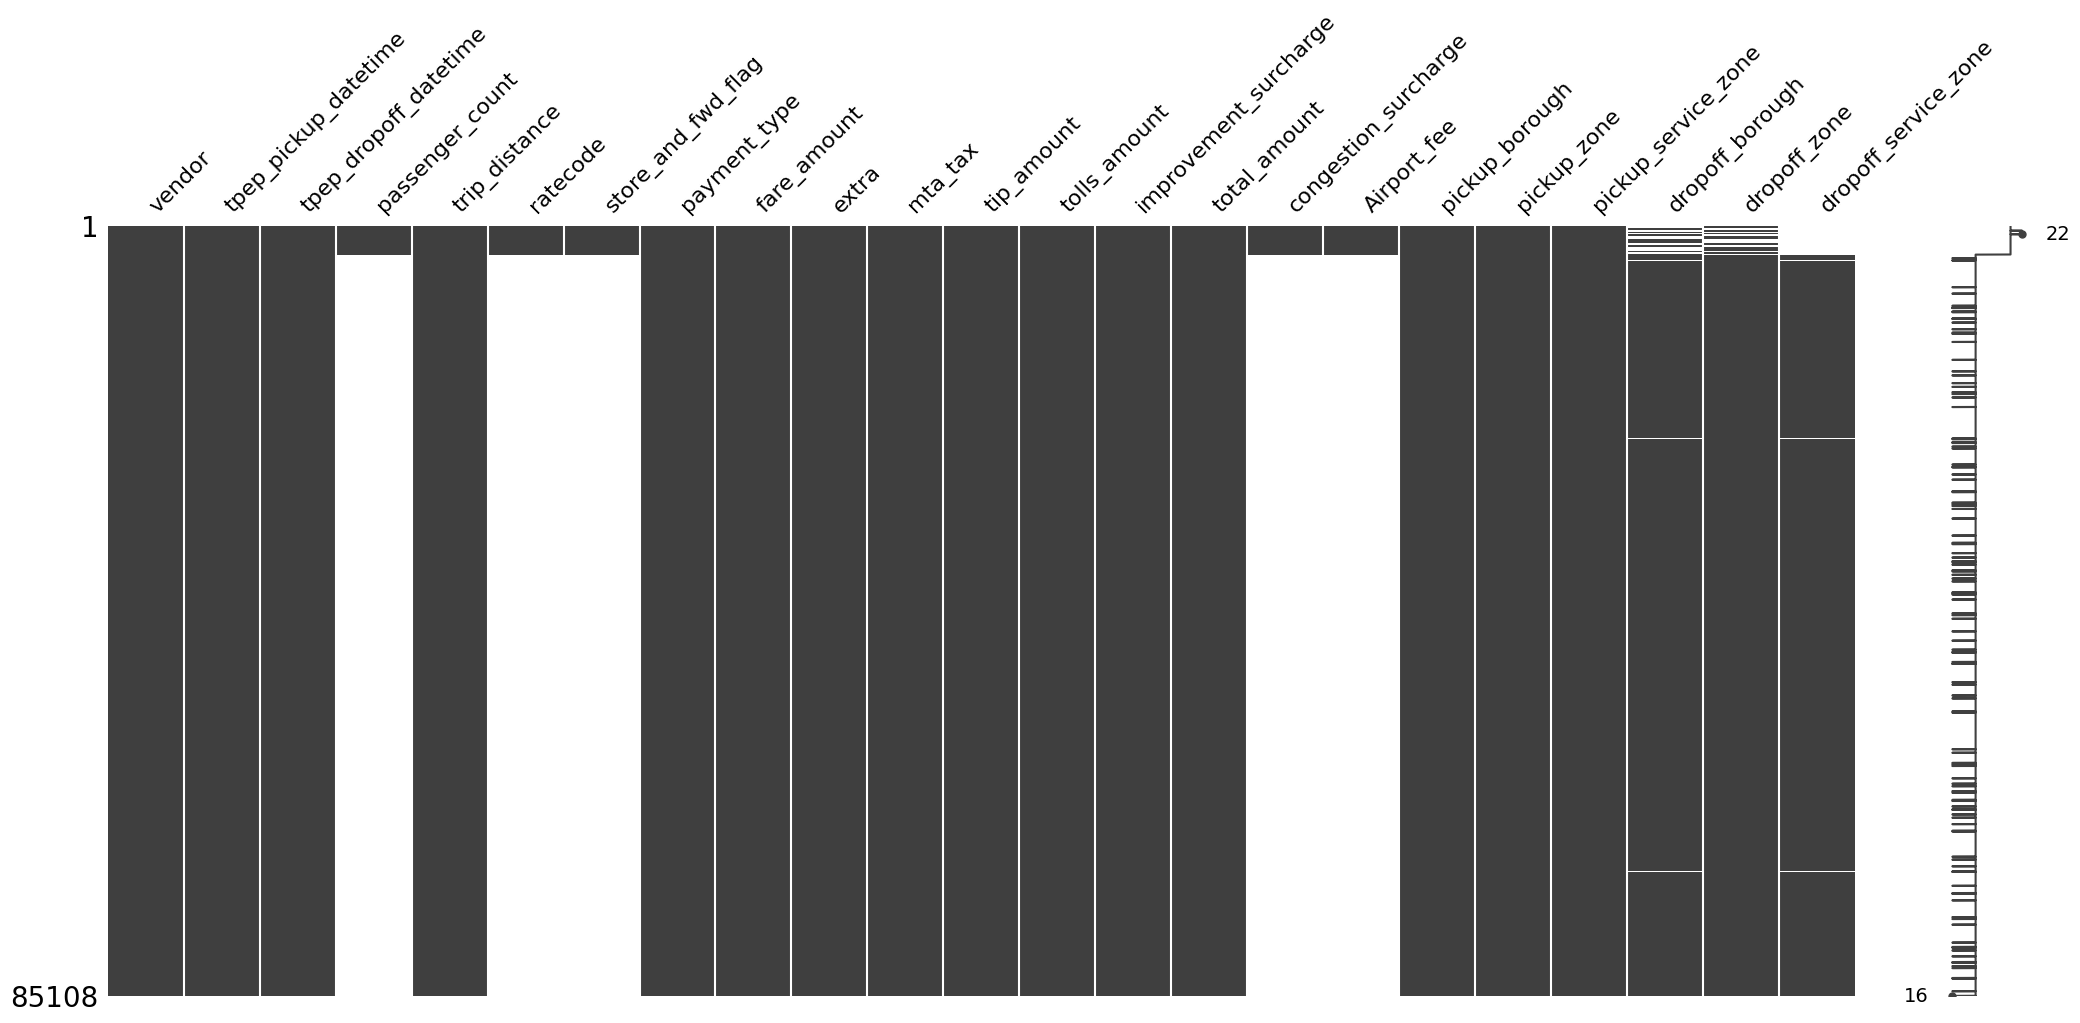

In [49]:
# mostramos matriz de missingno por vendor
nulos_subdf_vendor1 = nulos_subdf[nulos_subdf['vendor'] == 'Curb Mobility, LLC']
msno.matrix(nulos_subdf_vendor1)
plt.show()


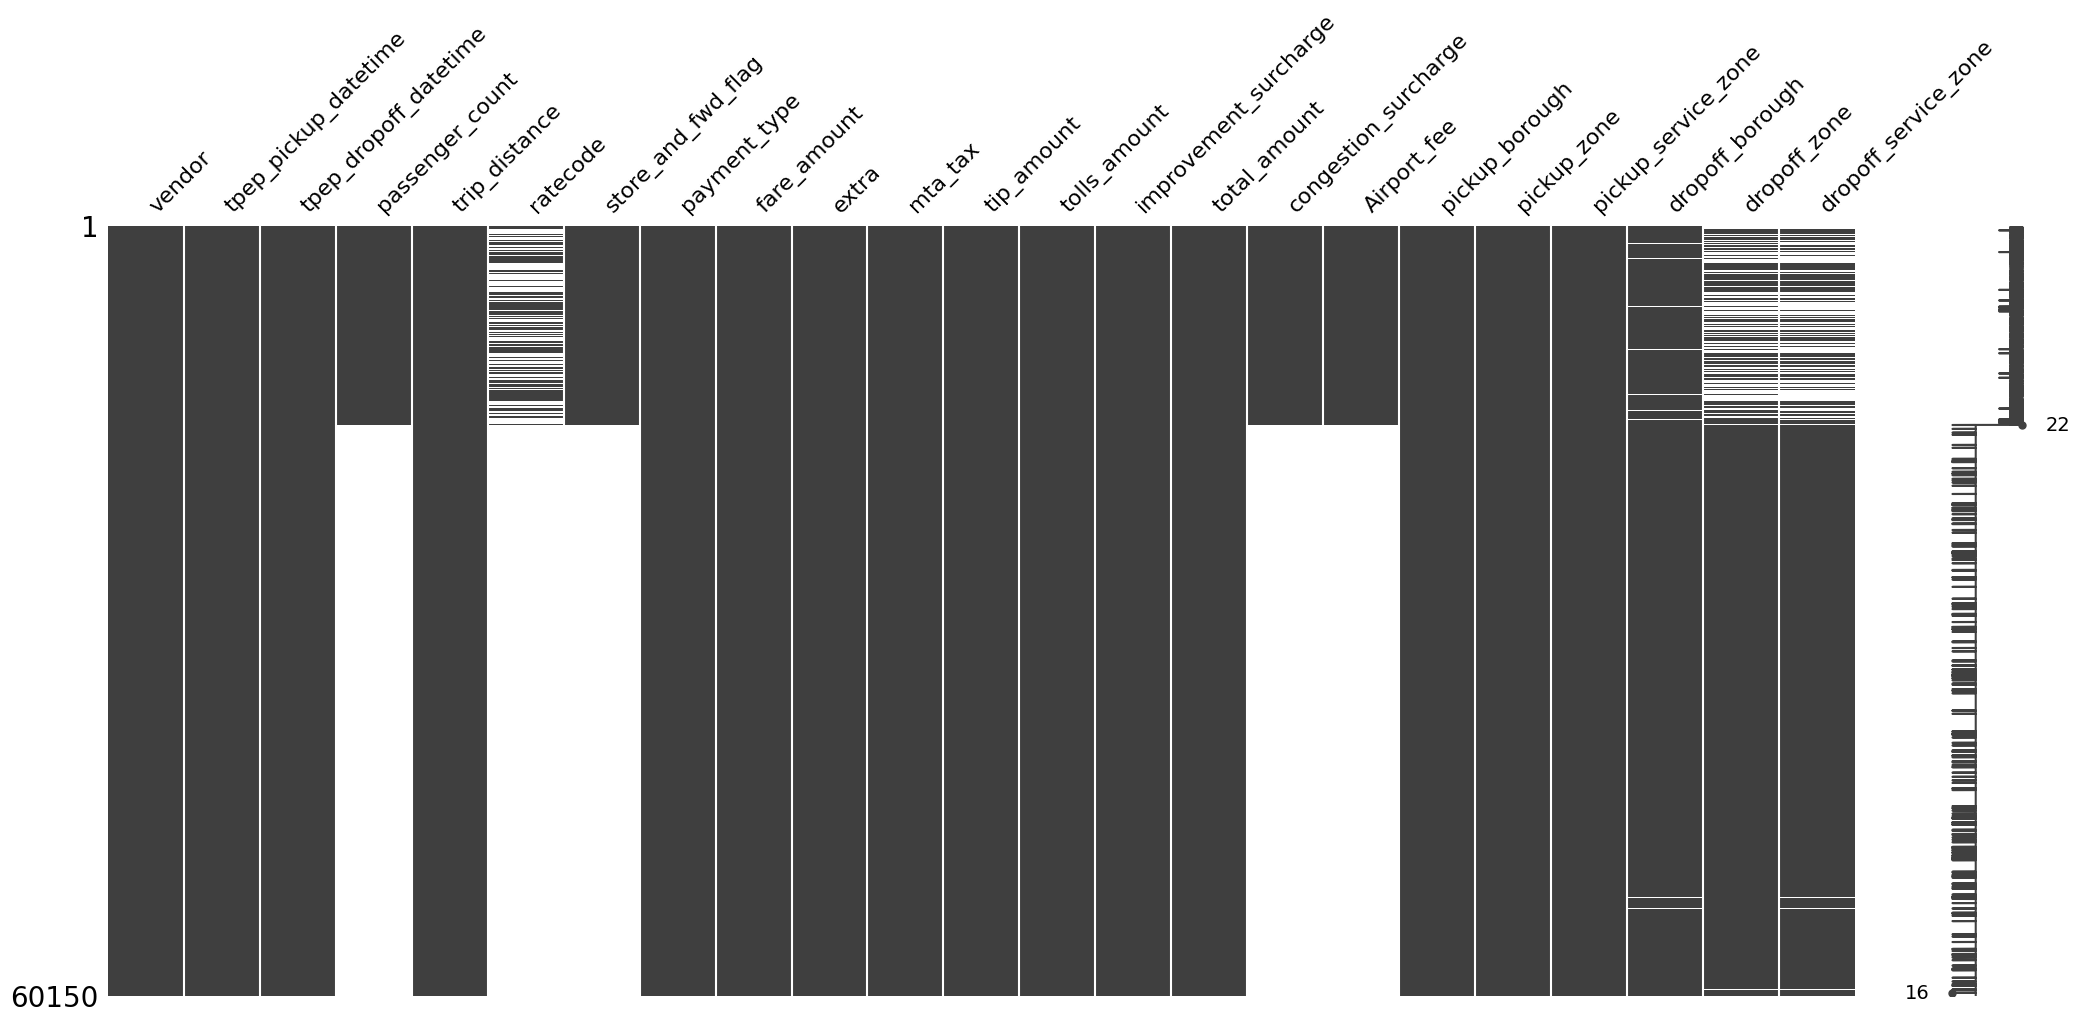

In [50]:
# mostramos matriz de missingno por vendor
nulos_subdf_vendor1 = nulos_subdf[nulos_subdf['vendor'] == 'Creative Mobile Technologies, LLC']
msno.matrix(nulos_subdf_vendor1)
plt.show()


In [51]:
# missigno por time series
nulos_subdf.set_index('tpep_pickup_datetime', inplace=True)


In [52]:
# missigno por time series
df.set_index('tpep_pickup_datetime', inplace=True)


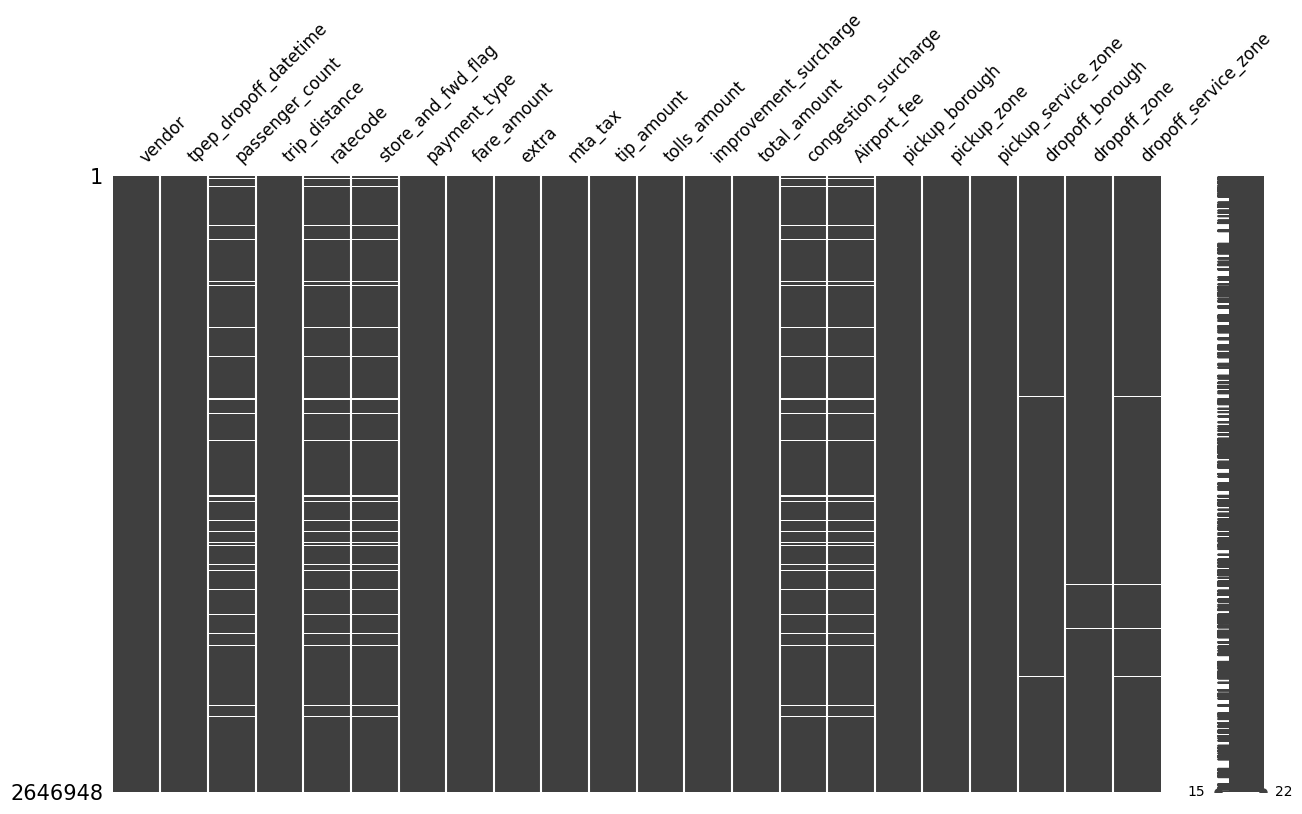

In [53]:
df.sort_index(inplace=True)
msno.matrix(df, figsize=(15,8), fontsize=12)
plt.show()

### Dropoff y pickup borough

In [ ]:
# dropoff borough nulos solo corresponden cuando el viaje termina en nueva york. Por lo tanto reemplazamos por "Outside of NYC" si dropoff_zone es "Outside of NYC"
df.loc[(df['dropoff_borough'].isnull()) & (df['dropoff_zone'] == 'Outside of NYC'), 'dropoff_borough'] = 'Outside of NYC'
# idem con pickup
df.loc[(df['pickup_borough'].isnull()) & (df['pickup_zone'] == 'Outside of NYC'), 'pickup_borough'] = 'Outside of NYC'


In [31]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df.isnull().mean() * 100
nulos_absolute = df.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                126558              4.78
trip_distance                       0              0.00
ratecode                       134912              5.10
store_and_fwd_flag             126558              4.78
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge           126558              4.78
Airport_fee                    126558              4.78
pickup_borough                      0           

### Filtro por NYC

In [58]:
# si filtramos las filas que no sean outside of NYC en pickup y dropoff
df_nyc = df[(df['pickup_zone'] != 'Outside of NYC') & (df['dropoff_zone'] != 'Outside of NYC')]

In [33]:
# cantidades de nulos para dropoff y pickup en total son bajos. podemos descartarlos a propositos del dataset. 
# drop nulls para dropoff y pickup
df_nyc = df_nyc.dropna(subset=['dropoff_borough','dropoff_zone','dropoff_service_zone','pickup_borough','pickup_zone', 'pickup_service_zone'])


In [34]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                126194              4.79
trip_distance                       0              0.00
ratecode                       134525              5.10
store_and_fwd_flag             126194              4.79
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge           126194              4.79
Airport_fee                    126194              4.79
pickup_borough                      0           

### Airport fee

In [35]:
# analicemos las filas que contienen nulos en airport_fee con un head
df_nyc[df_nyc['Airport_fee'].isnull()].head(5)


,vendor,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:58,"Curb Mobility, LLC",2024-01-01 00:27:23,<NA>,6.00,None,<NA>,Flex Fare trip,33.93,0.00,0.50,...,1.00,47.41,NaN,NaN,Manhattan,East Harlem North,Boro Zone,Manhattan,Midtown South,Yellow Zone
2024-01-01 00:02:21,"Creative Mobile Technologies, LLC",2024-01-01 00:18:59,<NA>,6.40,None,<NA>,Flex Fare trip,28.90,1.00,0.50,...,1.00,38.99,NaN,NaN,Manhattan,Clinton East,Yellow Zone,Manhattan,Hamilton Heights,Boro Zone
2024-01-01 00:02:36,"Creative Mobile Technologies, LLC",2024-01-01 00:26:02,<NA>,4.80,None,<NA>,Flex Fare trip,24.57,0.00,0.50,...,1.00,26.07,NaN,NaN,Manhattan,Greenwich Village South,Yellow Zone,Brooklyn,Bushwick South,Boro Zone
2024-01-01 00:03:35,"Creative Mobile Technologies, LLC",2024-01-01 00:19:54,<NA>,2.50,None,<NA>,Flex Fare trip,14.90,1.00,0.50,...,1.00,21.89,NaN,NaN,Manhattan,Kips Bay,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone
2024-01-01 00:03:36,"Creative Mobile Technologies, LLC",2024-01-01 00:09:07,<NA>,0.00,None,<NA>,Flex Fare trip,8.58,0.00,0.50,...,1.00,12.58,NaN,NaN,Manhattan,Meatpacking/West Village West,Yellow Zone,Manhattan,East Chelsea,Yellow Zone


In [36]:
# convertir objects a categoricas
categorical_cols = ['vendor', 'ratecode', 'payment_type', 'pickup_borough', 'pickup_zone', 'pickup_service_zone', 'dropoff_borough', 'dropoff_zone', 'dropoff_service_zone']
for col in categorical_cols:
    df_nyc[col] = df_nyc[col].astype('category')
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2636215 entries, 2002-12-31 22:59:39 to 2024-02-01 00:01:15
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   vendor                 category      
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        Int64         
 3   trip_distance          float64       
 4   ratecode               category      
 5   store_and_fwd_flag     boolean       
 6   payment_type           category      
 7   fare_amount            float64       
 8   extra                  float64       
 9   mta_tax                float64       
 10  tip_amount             float64       
 11  tolls_amount           float64       
 12  improvement_surcharge  float64       
 13  total_amount           float64       
 14  congestion_surcharge   float64       
 15  Airport_fee            float64       
 16  pickup_borough         category      
 17  pickup_zone            category 

In [37]:
df_nyc.describe(include='category')

,vendor,ratecode,payment_type,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
count,2636215,2501690,2636215,2636215,2636215,2636215,2636215,2636215,2636215
unique,2,6,5,1,67,2,6,256,4
top,"Curb Mobility, LLC",Standard rate,Credit card,Manhattan,Midtown Center,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone
freq,1993060,2462223,2079083,2636215,142942,2581206,2492571,137411,2373086


In [38]:
# verificar si algun airport_fee nulo tiene ratecode JFK o Newark
df_nyc[(df_nyc['Airport_fee'].isnull()) & (df_nyc['ratecode'].isin(['JFK', 'Newark']))]
# ninguno

,vendor,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,,,,


In [39]:
# Definimos la condición: Zona de recogida es 'Airports' Y la tarifa de aeropuerto es nula
df_nyc[(df_nyc['pickup_service_zone'] == 'Airports') & (df_nyc['Airport_fee'].isnull())].shape[0]


0

In [40]:
condicion_imputacion = (
    df_nyc['Airport_fee'].isnull() & 
    (
        (df_nyc['pickup_service_zone'] == 'Airports') | 
        (df_nyc['dropoff_service_zone'] == 'Airports')
    )
)
# 1.75 a los que cumplen condicion
df_nyc.loc[condicion_imputacion, 'Airport_fee'] = 1.75
# 0 a los que no
df_nyc['Airport_fee'] = df_nyc['Airport_fee'].fillna(0)

In [41]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                126194              4.79
trip_distance                       0              0.00
ratecode                       134525              5.10
store_and_fwd_flag             126194              4.79
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge           126194              4.79
Airport_fee                         0              0.00
pickup_borough                      0           

### Congestion surcharge

In [42]:
# analicemos el congestion_surcharge
# temporalmente creamos bins de horarios a partir de tpep_pickup_datetime para ver si hay alguna relación entre horario y congestion_surcharge
df_nyc['pickup_hour'] = df_nyc['tpep_pickup_datetime'].dt.hour
df_nyc['hour_bin'] = pd.cut(df_nyc['pickup_hour'], bins=[-1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24], 
                            labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-22', '22-24'])

# grafico de barras de congestion_surcharge por hour_bin
plt.figure(figsize=(10,6))
sns.barplot(data=df_nyc, x='hour_bin', y='congestion_surcharge', ci=None)
plt.title('Congestion Surcharge by Pickup Hour Bin')
plt.xlabel('Pickup Hour Bin')
plt.show()

KeyError: 'tpep_pickup_datetime'

In [43]:
# plot de sum de registros de congestion_surcharge por pickup hour cuando congestion_surcharge > 0
plt.figure(figsize=(10,6))
sns.barplot(data=df_nyc[df_nyc['congestion_surcharge'] > 0].groupby('pickup_hour')['congestion_surcharge'].sum().reset_index(), x='pickup_hour', y='congestion_surcharge', ci=None)
plt.title('Total Congestion Surcharge by Pickup Hour (Only > 0)')
plt.xlabel('Pickup Hour')
plt.show()

KeyError: 'pickup_hour'

<Figure size 1000x600 with 0 Axes>

In [20]:
# Calculamos probabilidad de que congestion_surcharge > 0 por pickup_hour
prob_congestion_by_hour = df_nyc.groupby('pickup_hour')['congestion_surcharge'].apply(lambda x: (x > 0).mean()).reset_index(name='prob_congestion_surcharge_gt_0')
# en base a esto imputamos a los valores nulos el valor 2.5 con una probabilidad igual a la calculada de que congestion_surcharge > 0 por pickup_hour
def imputar_congestion_surcharge(row):
    if pd.isnull(row['congestion_surcharge']):
        prob = prob_congestion_by_hour.loc[prob_congestion_by_hour['pickup_hour'] == row['pickup_hour'], 'prob_congestion_surcharge_gt_0'].values[0]
        if np.random.rand() < prob:
            return 2.5
        else:
            return 0.0
    else:
        return row['congestion_surcharge']
df_nyc['congestion_surcharge'] = df_nyc.apply(imputar_congestion_surcharge, axis=1)


In [21]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                139314              4.75
trip_distance                       0              0.00
ratecode                       167859              5.72
store_and_fwd_flag             139314              4.75
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge                0              0.00
Airport_fee                         0           

### Passenger count 

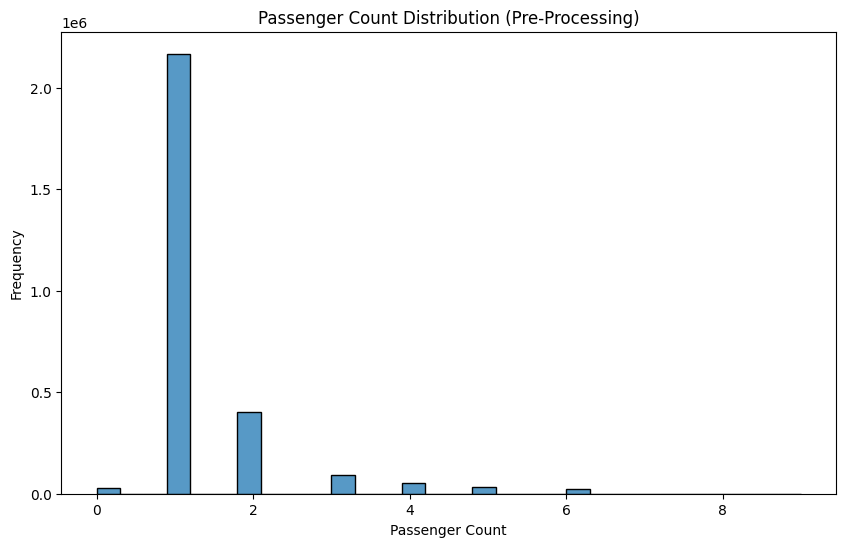

In [22]:
# histograma passenger count pre procesamiento
plt.figure(figsize=(10,6))
sns.histplot(df_nyc['passenger_count'].dropna(), bins=30, kde=False)
plt.title('Passenger Count Distribution (Pre-Processing)')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# ver de ponerlo con la media si es que usamos este dato

In [23]:
# passenger count lo imputamos por criterio de serie temporal. primero ffill luego bfill para asegurar completitud.
df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                     0              0.00
trip_distance                       0              0.00
ratecode                       167859              5.72
store_and_fwd_flag             139314              4.75
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge                0              0.00
Airport_fee                         0           

C:\Users\60080956\AppData\Local\Temp\ipykernel_20160\620267316.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')


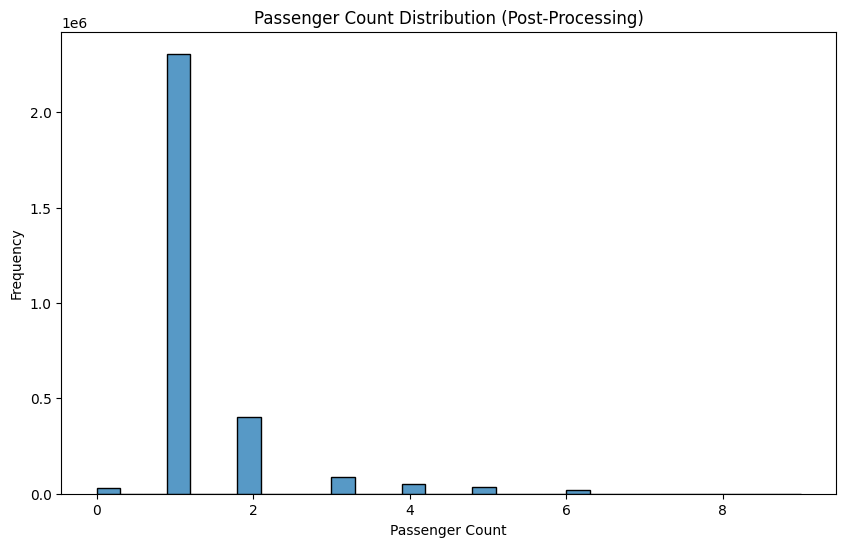

In [24]:
# histograma passenger count pos procesamiento
plt.figure(figsize=(10,6))
sns.histplot(df_nyc['passenger_count'].dropna(), bins=30, kde=False)
plt.title('Passenger Count Distribution (Post-Processing)')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.show()

### Store and fwd

In [25]:
# store and fwd no agrega valor al analisis
df_nyc = df_nyc.drop(columns=['store_and_fwd_flag'])

### Ratecode

In [27]:
# analicemos las filas que sean ratecode JFK o Newark y veamos valores de pickup y dropoff 
df_nyc[df_nyc['ratecode'].isin(['Newark'])].head(10)


,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,payment_type,fare_amount,extra,mta_tax,...,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,pickup_hour,hour_bin
1856,"Curb Mobility, LLC",2024-01-01 00:37:22,2024-01-01 01:21:01,4,17.43,Newark,Credit card,93.00,1.00,0.00,...,0.00,0.00,Manhattan,Lincoln Square East,Yellow Zone,EWR,Newark Airport,EWR,0,0-2
4787,"Curb Mobility, LLC",2024-01-01 00:07:49,2024-01-01 00:08:18,1,0.47,Newark,Cash,24.40,1.00,0.00,...,0.00,0.00,Queens,South Ozone Park,Boro Zone,Queens,JFK Airport,Airports,0,0-2
5010,"Curb Mobility, LLC",2024-01-01 00:45:47,2024-01-01 01:06:28,3,5.21,Newark,Credit card,47.50,1.00,0.00,...,0.00,0.00,Manhattan,Clinton West,Yellow Zone,Manhattan,East Harlem North,Boro Zone,0,0-2
5219,"Curb Mobility, LLC",2024-01-01 00:05:40,2024-01-01 01:00:23,1,16.13,Newark,Cash,83.90,1.00,0.00,...,0.00,1.75,Queens,JFK Airport,Airports,Brooklyn,Prospect-Lefferts Gardens,Boro Zone,0,0-2
5262,"Curb Mobility, LLC",2024-01-01 00:15:16,2024-01-01 00:15:41,2,0.06,Newark,Cash,23.00,1.00,0.00,...,0.00,0.00,Manhattan,Midtown North,Yellow Zone,Manhattan,Midtown North,Yellow Zone,0,0-2
5667,"Creative Mobile Technologies, LLC",2024-01-01 01:28:22,2024-01-01 01:35:01,2,0.80,Newark,Dispute,27.90,1.00,0.00,...,0.00,0.00,Manhattan,Flatiron,Yellow Zone,Manhattan,West Village,Yellow Zone,1,0-2
6283,"Curb Mobility, LLC",2024-01-01 01:55:48,2024-01-01 02:37:02,2,17.75,Newark,Credit card,92.30,1.00,0.00,...,0.00,0.00,Manhattan,Midtown North,Yellow Zone,EWR,Newark Airport,EWR,1,0-2
8306,"Curb Mobility, LLC",2024-01-01 01:46:42,2024-01-01 01:47:00,1,0.00,Newark,Credit card,23.00,1.00,0.00,...,0.00,0.00,Manhattan,UN/Turtle Bay South,Yellow Zone,Manhattan,UN/Turtle Bay South,Yellow Zone,1,0-2
8736,"Curb Mobility, LLC",2024-01-01 01:00:45,2024-01-01 01:00:59,3,0.00,Newark,Dispute,-23.00,-1.00,0.00,...,0.00,-1.75,Queens,JFK Airport,Airports,Queens,JFK Airport,Airports,1,0-2
8737,"Curb Mobility, LLC",2024-01-01 01:00:45,2024-01-01 01:00:59,3,0.00,Newark,Dispute,23.00,1.00,0.00,...,0.00,1.75,Queens,JFK Airport,Airports,Queens,JFK Airport,Airports,1,0-2


In [28]:
# analicemos las filas que sean ratecode JFK o Newark y veamos valores de pickup y dropoff 
df_nyc[df_nyc['ratecode'].isin(['JFK'])].head(5)


,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,payment_type,fare_amount,extra,mta_tax,...,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,pickup_hour,hour_bin
75,"Curb Mobility, LLC",2024-01-01 00:46:16,2024-01-01 01:20:10,1,20.85,JFK,Credit card,70.00,0.00,0.50,...,2.50,1.75,Queens,JFK Airport,Airports,Manhattan,Upper West Side South,Yellow Zone,0,0-2
137,"Curb Mobility, LLC",2024-01-01 00:06:29,2024-01-01 00:31:26,2,16.40,JFK,Cash,70.00,0.00,0.50,...,2.50,1.75,Queens,JFK Airport,Airports,Manhattan,Murray Hill,Yellow Zone,0,0-2
229,"Curb Mobility, LLC",2024-01-01 00:33:08,2024-01-01 00:59:55,2,20.59,JFK,Credit card,70.00,0.00,0.50,...,2.50,1.75,Queens,JFK Airport,Airports,Manhattan,Lenox Hill West,Yellow Zone,0,0-2
324,"Creative Mobile Technologies, LLC",2024-01-01 00:42:26,2024-01-01 01:12:01,0,16.60,JFK,Credit card,70.00,4.25,0.50,...,2.50,1.75,Queens,JFK Airport,Airports,Manhattan,UN/Turtle Bay South,Yellow Zone,0,0-2
459,"Curb Mobility, LLC",2024-01-01 00:46:16,2024-01-01 00:46:31,1,0.02,JFK,Cash,70.00,0.00,0.50,...,2.50,0.00,Manhattan,Upper West Side South,Yellow Zone,Manhattan,Upper West Side South,Yellow Zone,0,0-2


In [29]:
# podemos completar ratecode JFK y Newark si pickup_zone = 'JFK Airport' o dropoff_zone = 'JFK Airport'
condicion_ratecode_jfk = (
    df_nyc['ratecode'].isnull() & 
    (
        (df_nyc['pickup_zone'] == 'JFK Airport') | 
        (df_nyc['dropoff_zone'] == 'JFK Airport')
    )
)

df_nyc.loc[condicion_ratecode_jfk, 'ratecode'] = 'JFK'

# con newark no podemos porque no esta identificado como pickup o dropoff zone

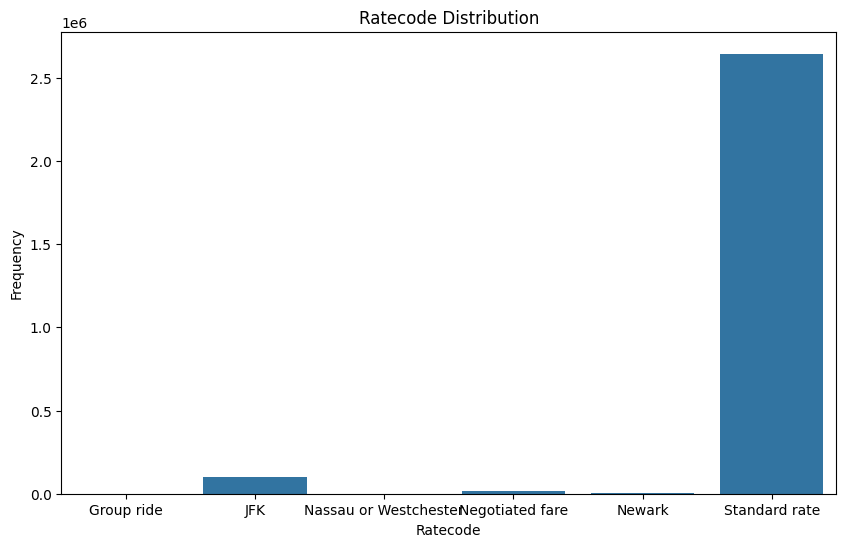

In [30]:
# analicemos distribucion de variable ratecode 
plt.figure(figsize=(10,6))
sns.countplot(data=df_nyc, x='ratecode')
plt.title('Ratecode Distribution')
plt.xlabel('Ratecode')
plt.ylabel('Frequency')
plt.show()

In [31]:
# analisis de variables para filas que sean ratecode negotiaded fare
# categoricas
df_nyc.nunique()

vendor                         2
tpep_pickup_datetime     1566682
tpep_dropoff_datetime    1565684
passenger_count               10
trip_distance               3510
ratecode                       6
payment_type                   5
fare_amount                 8309
extra                         46
mta_tax                        6
tip_amount                  3529
tolls_amount                 969
improvement_surcharge          5
total_amount               16392
congestion_surcharge           6
Airport_fee                    3
pickup_borough                 6
pickup_zone                  256
pickup_service_zone            4
dropoff_borough                6
dropoff_zone                 258
dropoff_service_zone           4
pickup_hour                   24
hour_bin                      12
dtype: int64

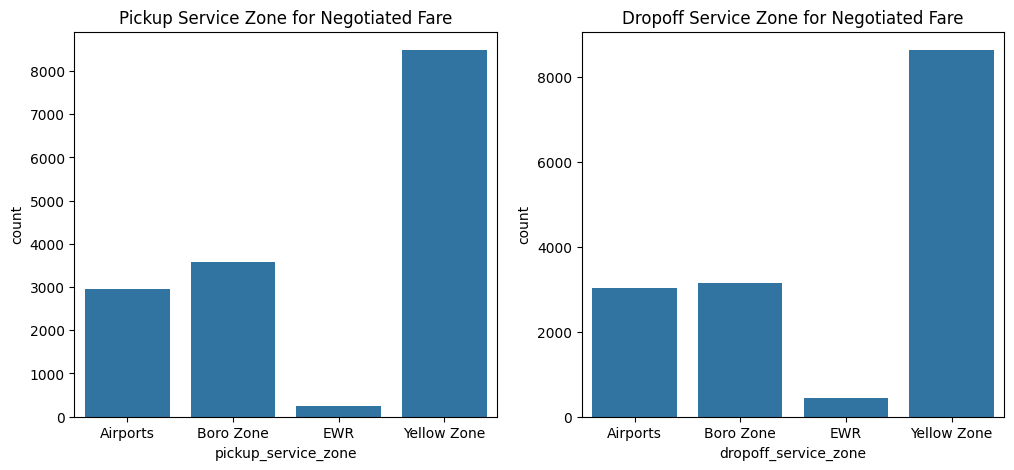

In [32]:
# filas que sean dropoff negotiaded fare head subplots de histograma de count de pickup_service_zone y dropoff_service_zone
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_nyc[df_nyc['ratecode'] == 'Negotiated fare'], x='pickup_service_zone')
plt.title('Pickup Service Zone for Negotiated Fare')
plt.subplot(1, 2, 2)
sns.countplot(data=df_nyc[df_nyc['ratecode'] == 'Negotiated fare'], x='dropoff_service_zone')
plt.title('Dropoff Service Zone for Negotiated Fare')
plt.show()

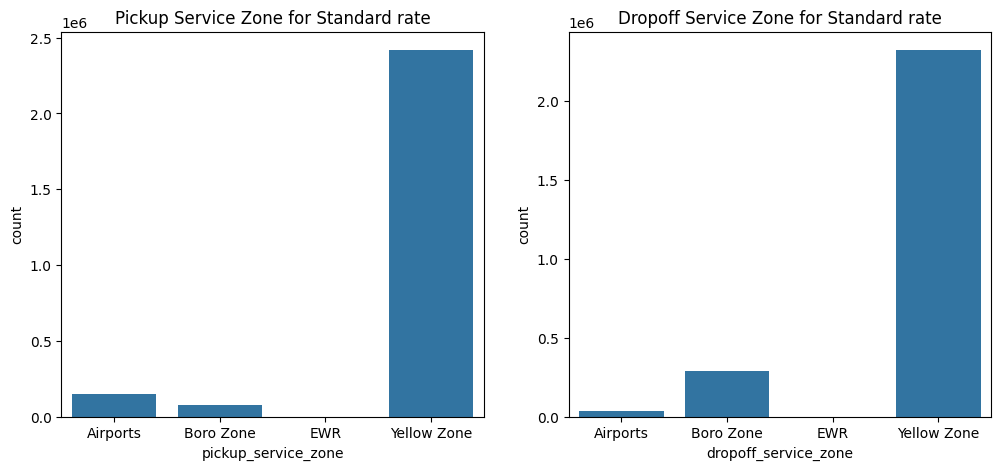

In [33]:
# para standard rate 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_nyc[df_nyc['ratecode'] == 'Standard rate'], x='pickup_service_zone')
plt.title('Pickup Service Zone for Standard rate')
plt.subplot(1, 2, 2)
sns.countplot(data=df_nyc[df_nyc['ratecode'] == 'Standard rate'], x='dropoff_service_zone')
plt.title('Dropoff Service Zone for Standard rate')
plt.show()

In [ ]:
# 

In [34]:
# viendo esto podemos imputar estocasticamente ratecode en funcion de pickup_service_zone 
# creando tabla de probabilidades de ratecode por pickup_service_zone
ratecode_probs = df_nyc.groupby('pickup_service_zone')['ratecode'].value_counts(normalize=True).unstack().fillna(0)
# función para imputar ratecode basado en probabilidades
def imputar_ratecode(row):
    if pd.isnull(row['ratecode']):
        probs = ratecode_probs.loc[row['pickup_service_zone']]
        return np.random.choice(probs.index, p=probs.values)
    else:
        return row['ratecode']
df_nyc['ratecode'] = df_nyc.apply(imputar_ratecode, axis=1)

C:\Users\60080956\AppData\Local\Temp\ipykernel_20160\3100907202.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratecode_probs = df_nyc.groupby('pickup_service_zone')['ratecode'].value_counts(normalize=True).unstack().fillna(0)


In [ ]:
df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

C:\Users\60080956\AppData\Local\Temp\ipykernel_20160\620267316.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')


                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                     0              0.00
trip_distance                       0              0.00
ratecode                            0              0.00
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge                0              0.00
Airport_fee                         0              0.00
pickup_borough                      0           

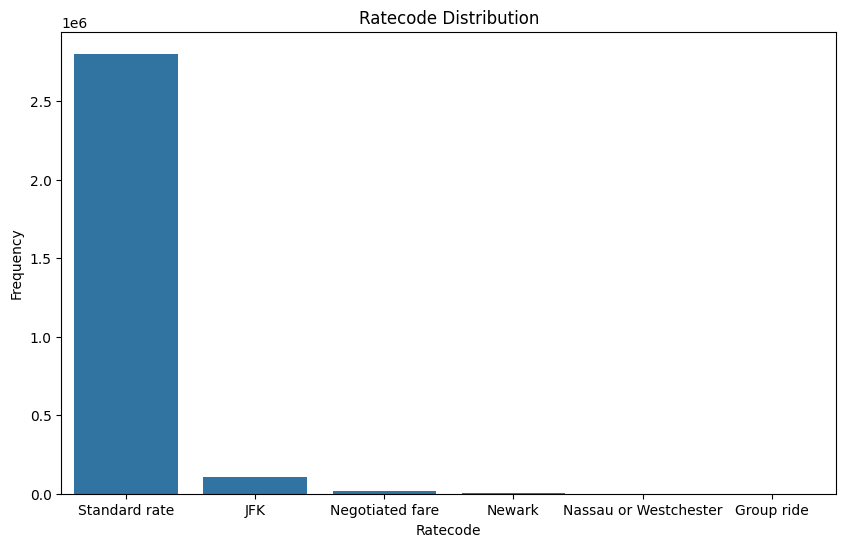

In [36]:
# analicemos distribucion de variable ratecode 
plt.figure(figsize=(10,6))
sns.countplot(data=df_nyc, x='ratecode')
plt.title('Ratecode Distribution')
plt.xlabel('Ratecode')
plt.ylabel('Frequency')
plt.show()

### Export 

In [38]:
# exportamos df limpio en formato parquet. para esto separamos por mes para no tener archivos muy grandes
# agregamos columna mes y separamos
df_nyc['month'] = df_nyc['tpep_pickup_datetime'].dt.month
for month, group in df_nyc.groupby('month'):
    group.drop(columns=['month'], inplace=True)
    group.to_parquet(f"../dataset/04-null-processed/yellow_tripdata_2024-{month:02d}.parquet", index=False)


In [65]:
df["hour"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.hour
df.groupby("hour")["airport_nan"].mean()


hour
0    0.09
1    0.11
2    0.10
3    0.10
4    0.15
5    0.11
6    0.10
7    0.08
8    0.07
9    0.04
10   0.03
11   0.03
12   0.03
13   0.03
14   0.03
15   0.03
16   0.03
17   0.04
18   0.05
19   0.04
20   0.04
21   0.05
22   0.06
23   0.08
Name: airport_nan, dtype: float64

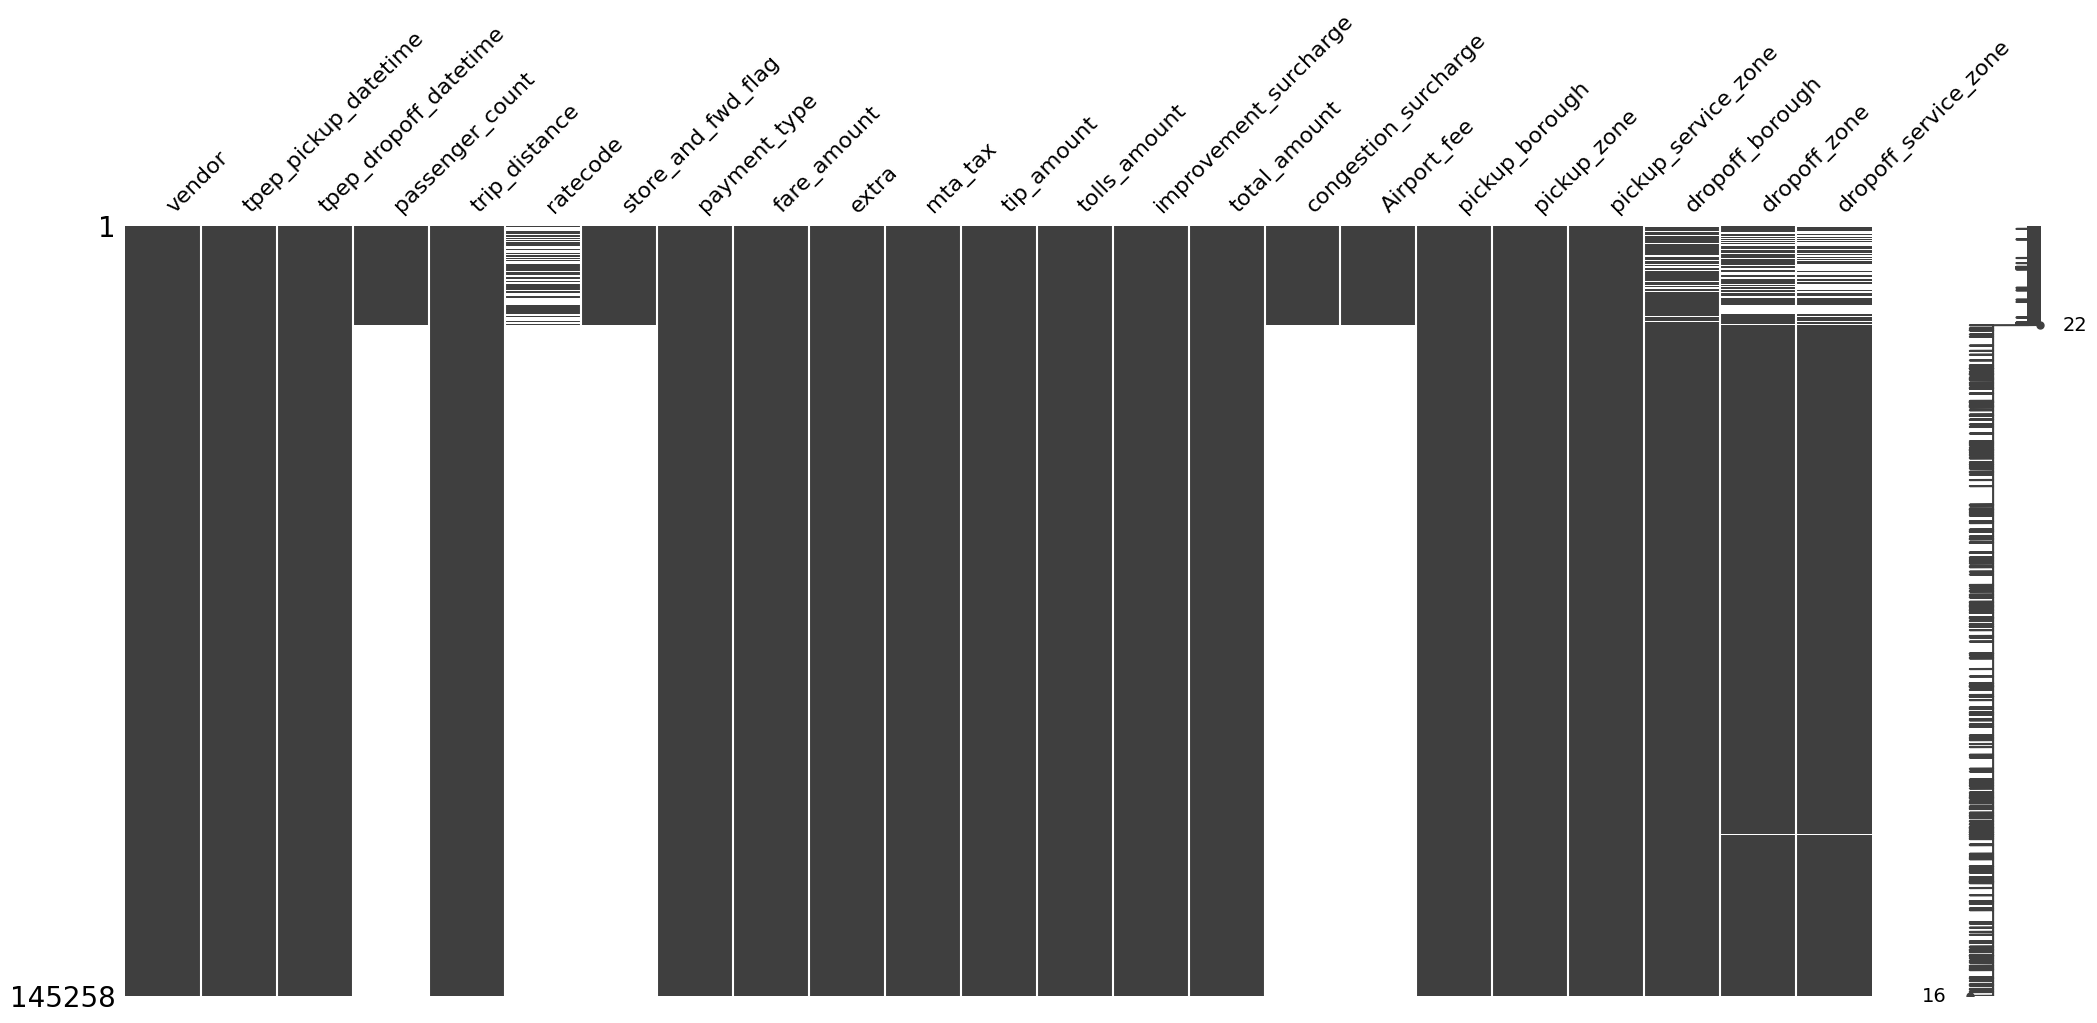

In [74]:
msno.matrix(nulos_subdf)
plt.show()

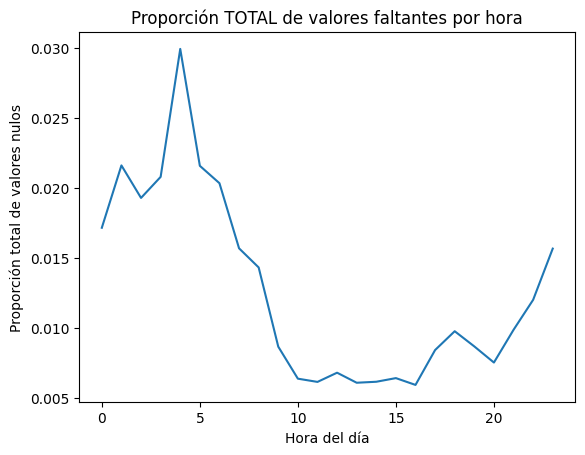

In [72]:
# 1. Crear la columna hour desde el datetime
df["hour"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.hour

# 2. Calcular la proporción TOTAL de nulos por hora (en todo el DataFrame)
prop_nulos_por_hora = df.isna().groupby(df["hour"]).mean().mean(axis=1)

# 3. Graficar la proporción total de nulos por hora
plt.figure()
plt.plot(prop_nulos_por_hora.index, prop_nulos_por_hora.values)
plt.xlabel("Hora del día")
plt.ylabel("Proporción total de valores nulos")
plt.title("Proporción TOTAL de valores faltantes por hora")
plt.show()

El gráfico de la proporción total de valores faltantes por hora del día evidencia la presencia de picos y valles claramente diferenciados, lo que indica que la probabilidad de ausencia de los datos no es constante a lo largo del tiempo. Este comportamiento descarta el supuesto de Missing Completely At Random (MCAR), ya que bajo dicho mecanismo los valores faltantes deberían distribuirse de forma aproximadamente uniforme. En cambio, la dependencia sistemática del missing respecto de una variable observada como la hora del día permite clasificar el mecanismo como Missing At Random (MAR), de naturaleza temporal, asociado a condiciones operativas del sistema de registro, conectividad y validación de la información.

Es posible que los datos faltantes, o la mayor parte de ellos, se deban a problemas relacionados a la conectividad de los sistemas de los taxis. 

Para el análisis de los datos del modelo de ML no complica porque esas columnas no tienen datos faltantes. 

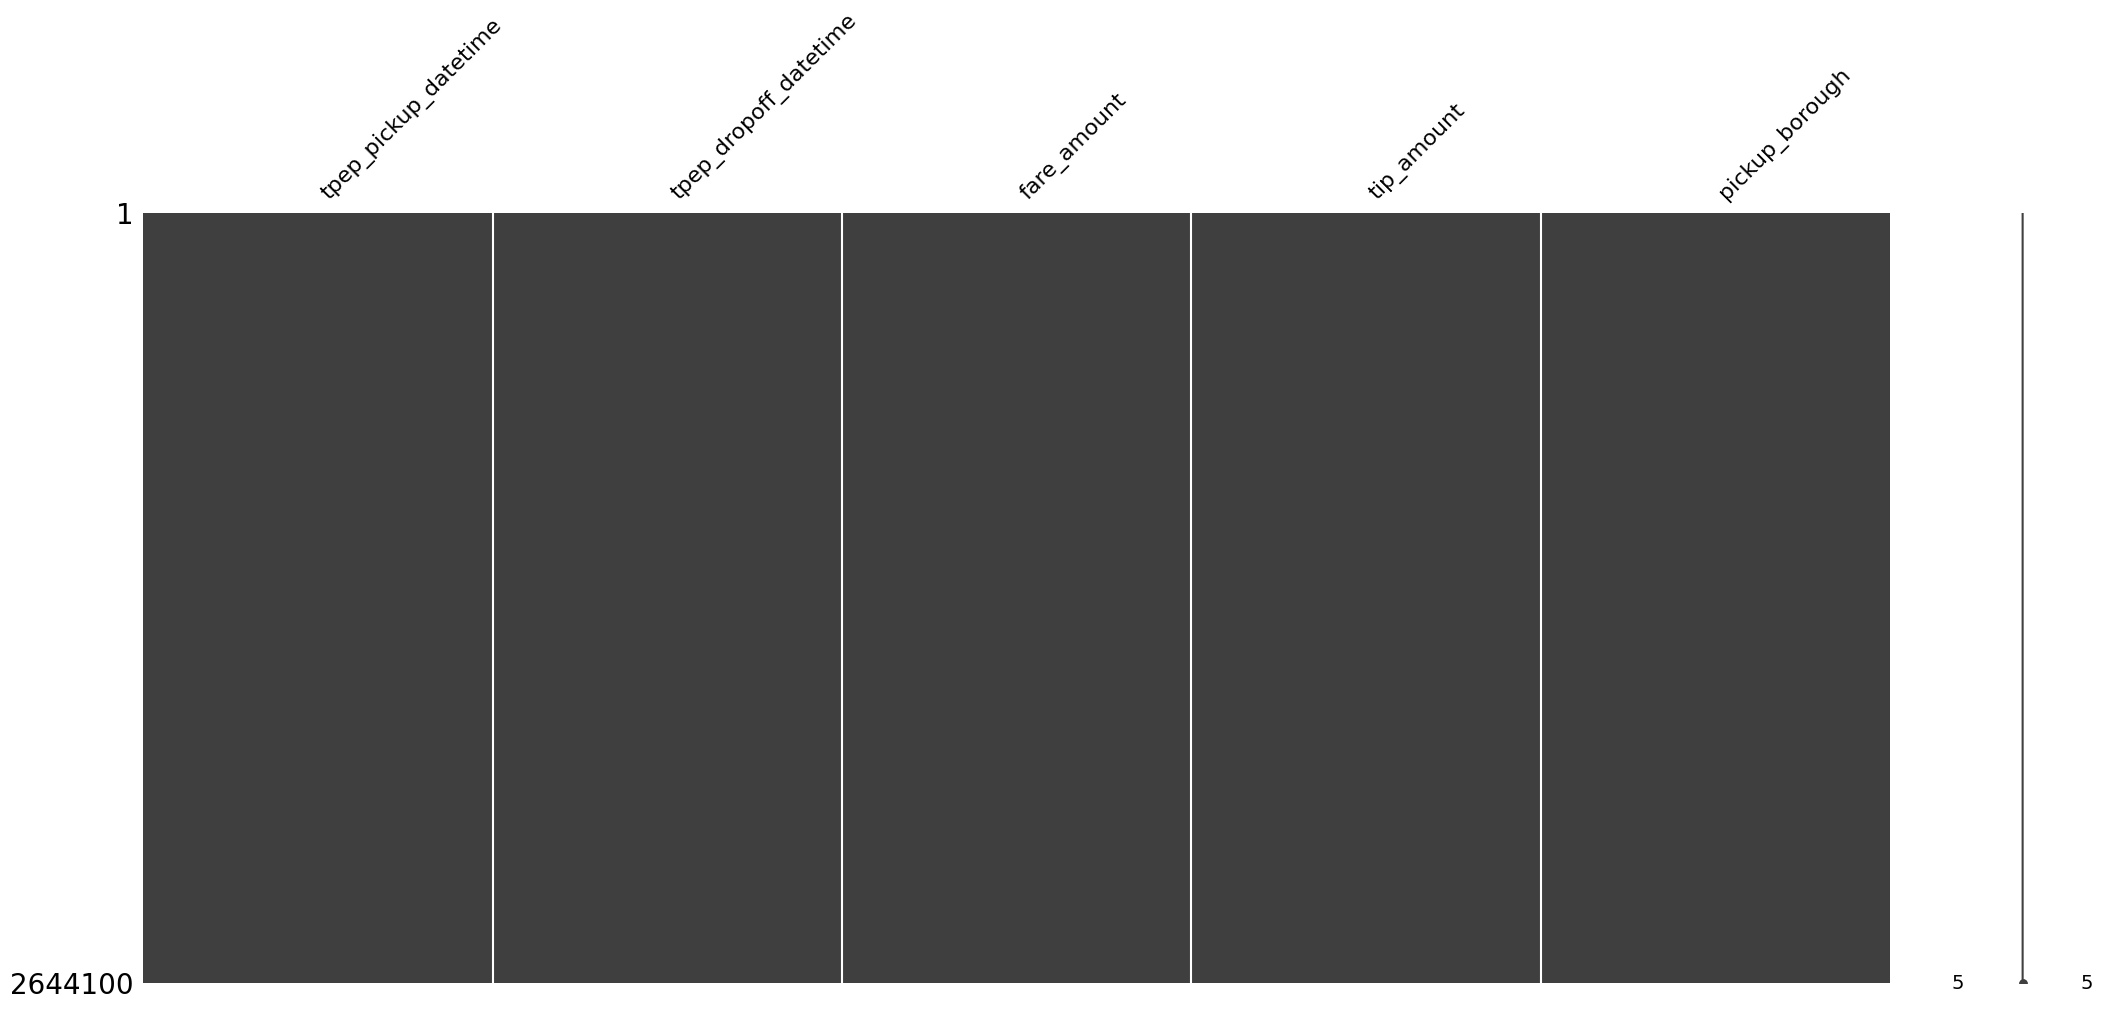

In [73]:
# filtramos solo columnas que utilizaremos en el analisis de AndD: tpep_pickup_datetime, tpep_dropoff_datetime, fare_amount, tip_amount, pickup_borough
df_nyc_filtrado = df_nyc[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'fare_amount', 'tip_amount', 'pickup_borough']]
msno.matrix(df_nyc_filtrado)
plt.show()